In [15]:
import pandas as pd
import numpy as np
import pingouin as pg
from statsmodels.stats.multicomp import MultiComparison
import matplotlib.pyplot as plt
from scipy.stats import t

In [16]:
rf = pd.read_csv("../results/cv5x5/rf_ecfp4/rf_metrics_long.csv")
cp = pd.read_csv("../results/cv5x5/chemprop_metrics_long.csv")
allm = pd.concat([rf, cp], ignore_index=True)

allm["method"] = allm["model_family"].str.upper() + "-" + allm["variant"]
allm["cv_sample"] = allm["cv_iter"].astype(str) + "_" + allm["fold"].astype(str)

allm.head()

,model_family,variant,task,cv_iter,fold,mae,rmse,r2,n_val,method,cv_sample
0,rf,single_papp,papp,0,0,6.164,8.235,0.3888,NaN,RF-single_papp,0_0
1,rf,single_efflux,efflux,0,0,3.416,8.230,0.2905,NaN,RF-single_efflux,0_0
2,rf,multi,papp,0,0,6.085,8.072,0.4127,NaN,RF-multi,0_0
3,rf,multi,efflux,0,0,3.376,8.103,0.3121,NaN,RF-multi,0_0
4,rf,single_papp,papp,0,1,6.434,8.575,0.3181,NaN,RF-single_papp,0_1


In [17]:
task = "papp"   # or "efflux"
metric = "mae"

df_task = allm[allm["task"] == task][["cv_sample", "method", metric]].copy()

# Repeated measures ANOVA:
rm = pg.rm_anova(data=df_task, dv=metric, within="method", subject="cv_sample", detailed=True)
rm

,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,method,2.028728,3,0.676243,23.130874,1.364919e-10,0.000001,0.124696,0.529715,False,0.137252,1.446930e-08
1,Error,2.104956,72,0.029235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                 group2         meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------------
        CHEMPROP-multi CHEMPROP-single_efflux   0.0238  0.999 -0.4162 0.4638  False
        CHEMPROP-multi               RF-multi  -0.2656 0.3959 -0.7055 0.1744  False
        CHEMPROP-multi       RF-single_efflux  -0.2076 0.6069 -0.6476 0.2323  False
CHEMPROP-single_efflux               RF-multi  -0.2894 0.3192 -0.7293 0.1506  False
CHEMPROP-single_efflux       RF-single_efflux  -0.2315 0.5177 -0.6714 0.2085  False
              RF-multi       RF-single_efflux   0.0579 0.9859  -0.382 0.4979  False
-----------------------------------------------------------------------------------


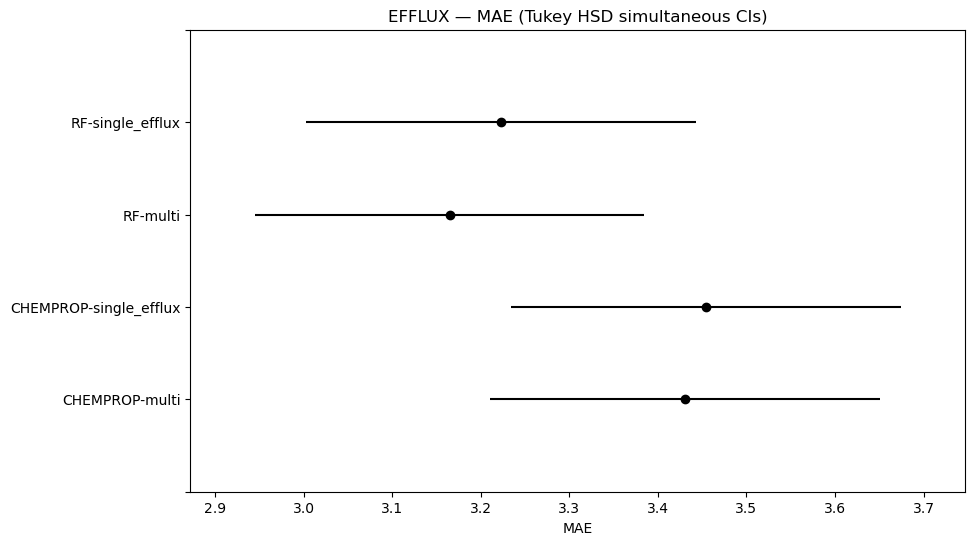

Best: RF-multi


,method,class
0,RF-multi,best
2,CHEMPROP-multi,similar
1,RF-single_papp,similar
3,CHEMPROP-single_papp,worse


In [27]:
mc = MultiComparison(df_task[metric], df_task["method"])
tuk = mc.tukeyhsd(alpha=0.05)
print(tuk.summary())
fig = tuk.plot_simultaneous(comparison_name=None)  # shows all methods with CIs
plt.title(f"{task.upper()} — {metric.upper()} (Tukey HSD simultaneous CIs)")
plt.xlabel(metric.upper())
plt.show()

print("Best:", best)
pd.DataFrame(
    {"method": list(class_map.keys()), "class": list(class_map.values())}
).sort_values(["class", "method"])

In [28]:
task = "efflux"
metric = "mae"

df_task = allm[allm["task"] == task][["cv_sample", "method", metric]].copy()

# Repeated measures ANOVA:
rm = pg.rm_anova(
    data=df_task, dv=metric, within="method", subject="cv_sample", detailed=True
)
rm

,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,method,1.592925,3,0.530975,10.840375,0.000006,0.000252,0.044781,0.596322,False,0.178621,2.323996e-07
1,Error,3.526649,72,0.048981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                 group2         meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------------
        CHEMPROP-multi CHEMPROP-single_efflux   0.0238  0.999 -0.4162 0.4638  False
        CHEMPROP-multi               RF-multi  -0.2656 0.3959 -0.7055 0.1744  False
        CHEMPROP-multi       RF-single_efflux  -0.2076 0.6069 -0.6476 0.2323  False
CHEMPROP-single_efflux               RF-multi  -0.2894 0.3192 -0.7293 0.1506  False
CHEMPROP-single_efflux       RF-single_efflux  -0.2315 0.5177 -0.6714 0.2085  False
              RF-multi       RF-single_efflux   0.0579 0.9859  -0.382 0.4979  False
-----------------------------------------------------------------------------------


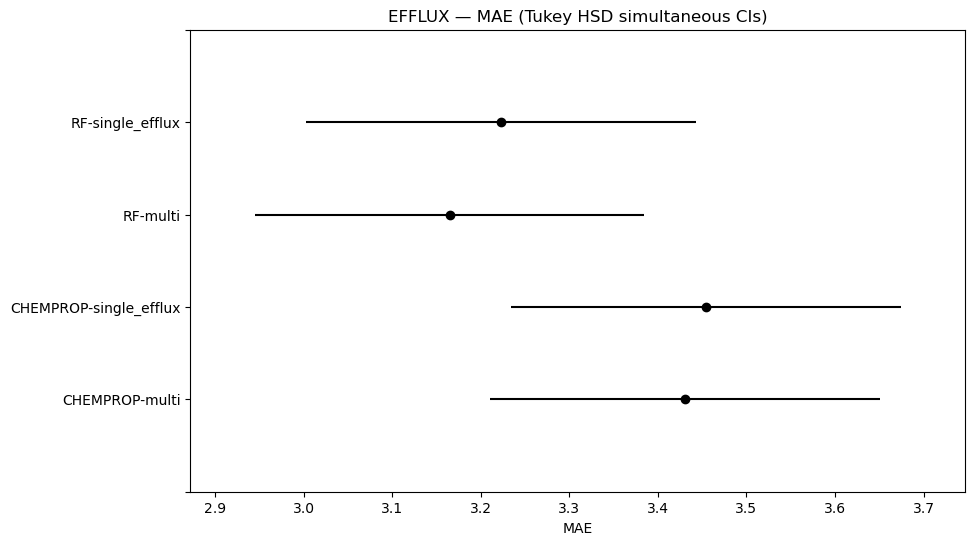

Best: RF-multi


,method,class
0,RF-multi,best
2,CHEMPROP-multi,similar
1,RF-single_papp,similar
3,CHEMPROP-single_papp,worse


In [29]:
mc = MultiComparison(df_task[metric], df_task["method"])
tuk = mc.tukeyhsd(alpha=0.05)
print(tuk.summary())
fig = tuk.plot_simultaneous(comparison_name=None)  # shows all methods with CIs
plt.title(f"{task.upper()} — {metric.upper()} (Tukey HSD simultaneous CIs)")
plt.xlabel(metric.upper())
plt.show()

print("Best:", best)
pd.DataFrame(
    {"method": list(class_map.keys()), "class": list(class_map.values())}
).sort_values(["class", "method"])

In [21]:
def mean_ci_95(x):
    """95% CI for the mean using a t-interval."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = float(x.mean())
    if n < 2:
        return mean, mean, mean, n
    sd = float(x.std(ddof=1))
    se = sd / np.sqrt(n)
    tcrit = float(t.ppf(0.975, df=n - 1))  # 95% CI
    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return mean, lo, hi, n


def tukey_vs_best_class(df_task, metric="mae", alpha=0.05):
    """
    Returns a summary dataframe with:
      method, mean, lo, hi, n, class  (best/similar/worse)
    Class is determined by Tukey HSD comparisons vs the best (lowest mean).
    """
    # Summary stats per method
    rows = []
    for method, g in df_task.groupby("method"):
        mean, lo, hi, n = mean_ci_95(g[metric].values)
        rows.append({"method": method, "mean": mean, "lo": lo, "hi": hi, "n": n})
    summ = pd.DataFrame(rows).sort_values("mean").reset_index(drop=True)

    best = summ.loc[0, "method"]

    # Tukey HSD
    mc = MultiComparison(df_task[metric].values, df_task["method"].values)
    tuk = mc.tukeyhsd(alpha=alpha)
    tuk_df = pd.DataFrame(tuk.summary().data[1:], columns=tuk.summary().data[0])

    # Determine which methods are significantly worse than best
    worse = set()
    for _, r in tuk_df.iterrows():
        g1, g2, reject = r["group1"], r["group2"], bool(r["reject"])
        if best not in (g1, g2):
            continue
        other = g2 if g1 == best else g1
        if reject:
            worse.add(other)

    def cls(m):
        if m == best:
            return "best"
        if m in worse:
            return "worse"
        return "similar"

    summ["class"] = summ["method"].apply(cls)
    return summ, tuk_df, best

In [22]:
def plot_forest(summ, title, xlabel="MAE"):
    # Ensure best (lowest mean) at top
    summ = summ.sort_values("mean", ascending=True).reset_index(drop=True)

    color_map = {"best": "blue", "similar": "gray", "worse": "red"}

    plt.figure(figsize=(10, max(4, 0.45 * len(summ))))
    for i, row in summ.iterrows():
        c = color_map[row["class"]]
        # whisker
        plt.plot([row["lo"], row["hi"]], [i, i], linewidth=2, color=c)
        # point estimate
        plt.plot(row["mean"], i, marker="o", markersize=6, color=c)

    plt.yticks(np.arange(len(summ)), summ["method"])
    plt.gca().invert_yaxis()
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

Best: RF-multi


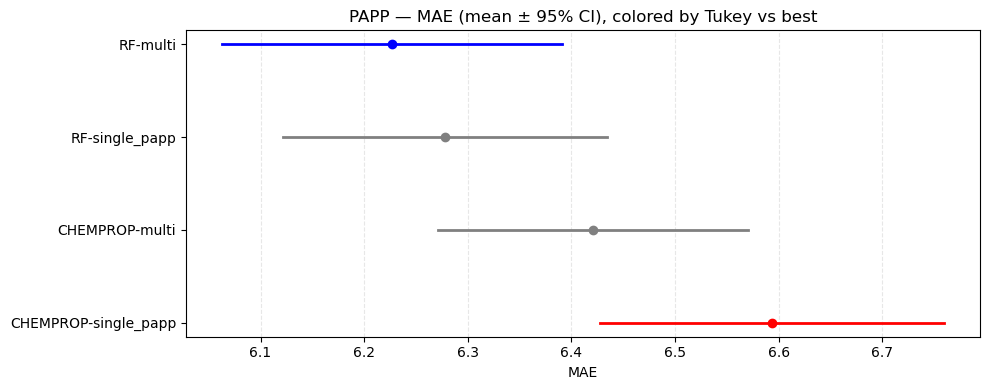

In [ ]:
task = "papp"
metric = "mae"

df_task = allm[allm["task"] == task][["cv_sample", "method", metric]].copy()

summ, tuk_df, best = tukey_vs_best_class(df_task, metric=metric, alpha=0.05)
print("Best:", best)

plot_forest(
    summ,
    title=f"{task.upper()} — {metric.upper()} (mean ± 95% CI), colored by Tukey vs best",
    xlabel=metric.upper(),
)

Best: RF-multi


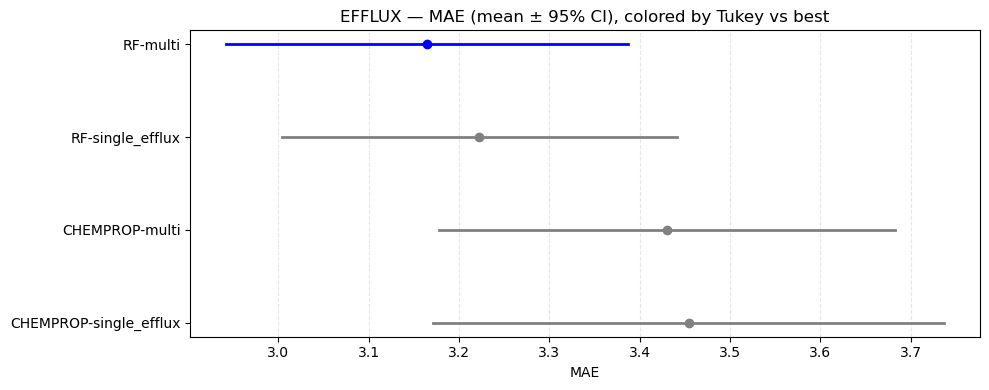

In [24]:
task = "efflux"
metric = "mae"

df_task = allm[allm["task"] == task][["cv_sample", "method", metric]].copy()

summ, tuk_df, best = tukey_vs_best_class(df_task, metric=metric, alpha=0.05)
print("Best:", best)

plot_forest(
    summ,
    title=f"{task.upper()} — {metric.upper()} (mean ± 95% CI), colored by Tukey vs best",
    xlabel=metric.upper(),
)